# SMHI Metro All Stations - Comprehensive Data Exploration

## Overview

This notebook provides an in-depth exploration of the **smhi_metro_all.csv** dataset, which contains meteorological data from all SMHI stations that have **multiple parameters** (snow depth + at least 2 other meteorological measurements).

### Dataset Background

The data was downloaded using `download_smhi_metro_all.py`, which:
1. **Dynamically discovered** all SMHI stations with 3+ parameters
2. **Downloaded data** from 2015-01-01 to 2025-12-31
3. **Aggregated hourly data** to daily values where needed

### Parameters Included

| Parameter | Unit | Description | Aggregation |
|-----------|------|-------------|-------------|
| snow | m | Snow depth | Last (06 UTC) |
| temp | °C | Air temperature (mean) | Daily mean |
| temp_min | °C | Air temperature (min) | Daily min |
| temp_max | °C | Air temperature (max) | Daily max |
| precip | mm | Precipitation | Daily sum |
| wind | m/s | Wind speed | Daily mean |
| humidity | % | Relative humidity | Daily mean |
| pressure | hPa | Sea-level pressure | Daily mean |
| dew_point | °C | Dew point temperature | Daily mean |
| cloud_cover | % | Total cloud cover | Daily mean |
| ground_state | code | Ground state code | Last |

### Analysis Goals

1. **Understand data structure** - rows, columns, data types
2. **Assess data coverage** - which parameters are available where and when
3. **Station analysis** - geographic distribution and data availability
4. **Temporal patterns** - seasonality, trends, gaps
5. **Parameter relationships** - correlations and dependencies
6. **Data quality** - missing values, outliers, anomalies
7. **Recommendations** - which data to use for model training

---
# Part 1: Setup and Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palette for consistent visualizations
COLORS = {
    'primary': '#3498db',
    'secondary': '#e74c3c',
    'success': '#27ae60',
    'warning': '#f39c12',
    'info': '#9b59b6',
    'snow': '#3498db',
    'temp': '#e74c3c',
    'precip': '#27ae60',
    'wind': '#f39c12',
    'pressure': '#9b59b6',
}

print("Libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries loaded successfully!
Pandas version: 2.3.3
NumPy version: 2.2.6


In [2]:
# Load the dataset
DATA_PATH = Path('../data/raw/smhi_metro_all.csv')

print(f"Loading data from: {DATA_PATH}")
print(f"File size: {DATA_PATH.stat().st_size / 1024**2:.2f} MB")

df = pd.read_csv(DATA_PATH, parse_dates=['date'])

print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Loading data from: ../data/raw/smhi_metro_all.csv
File size: 67.69 MB

Dataset loaded successfully!
Shape: 825,584 rows × 17 columns
Memory usage: 162.76 MB


---
# Part 2: Basic Data Structure

Let's understand the basic structure of our dataset - what columns we have, their data types, and initial statistics.

In [3]:
# Display first few rows
print("=" * 100)
print("FIRST 10 ROWS OF DATA")
print("=" * 100)
display(df.head(10))

FIRST 10 ROWS OF DATA


,date,station_id,station_name,latitude,longitude,elevation,snow,temp,temp_min,temp_max,precip,wind,humidity,pressure,dew_point,cloud_cover,ground_state
0,2015-01-01,188800,Abisko,68.35,18.82,393.38,0.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.00
1,2015-01-02,188800,Abisko,68.35,18.82,393.38,0.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.00
2,2015-01-05,188800,Abisko,68.35,18.82,393.38,0.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.00
3,2015-01-07,188800,Abisko,68.35,18.82,393.38,0.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.00
4,2015-01-08,188800,Abisko,68.35,18.82,393.38,0.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.00
5,2015-01-09,188800,Abisko,68.35,18.82,393.38,0.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.00
6,2015-01-12,188800,Abisko,68.35,18.82,393.38,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.00
7,2015-01-13,188800,Abisko,68.35,18.82,393.38,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.00
8,2015-01-14,188800,Abisko,68.35,18.82,393.38,0.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.00
9,2015-01-15,188800,Abisko,68.35,18.82,393.38,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.00


In [4]:
# Display last few rows
print("\n" + "=" * 100)
print("LAST 10 ROWS OF DATA")
print("=" * 100)
display(df.tail(10))


LAST 10 ROWS OF DATA


,date,station_id,station_name,latitude,longitude,elevation,snow,temp,temp_min,temp_max,precip,wind,humidity,pressure,dew_point,cloud_cover,ground_state
825574,2025-09-22,173810,Övertorneå,66.39,23.62,59.51,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
825575,2025-09-23,173810,Övertorneå,66.39,23.62,59.51,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
825576,2025-09-24,173810,Övertorneå,66.39,23.62,59.51,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
825577,2025-09-25,173810,Övertorneå,66.39,23.62,59.51,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
825578,2025-09-26,173810,Övertorneå,66.39,23.62,59.51,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
825579,2025-09-27,173810,Övertorneå,66.39,23.62,59.51,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
825580,2025-09-28,173810,Övertorneå,66.39,23.62,59.51,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
825581,2025-09-29,173810,Övertorneå,66.39,23.62,59.51,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
825582,2025-09-30,173810,Övertorneå,66.39,23.62,59.51,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
825583,2025-10-01,173810,Övertorneå,66.39,23.62,59.51,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00


In [5]:
# Data types and info
print("=" * 100)
print("DATA TYPES AND MEMORY")
print("=" * 100)
print(f"\n{'Column':<20} {'Dtype':<15} {'Memory (MB)':<15} {'Non-Null':>12} {'Null':>10}")
print("-" * 75)

for col in df.columns:
    mem = df[col].memory_usage(deep=True) / 1024**2
    non_null = df[col].notna().sum()
    null = df[col].isna().sum()
    print(f"{col:<20} {str(df[col].dtype):<15} {mem:<15.3f} {non_null:>12,} {null:>10,}")

DATA TYPES AND MEMORY

Column               Dtype           Memory (MB)         Non-Null       Null
---------------------------------------------------------------------------
date                 datetime64[ns]  6.299                825,584          0
station_id           int64           6.299                825,584          0
station_name         object          61.984               825,584          0
latitude             float64         6.299                825,584          0
longitude            float64         6.299                825,584          0
elevation            float64         6.299                825,584          0
snow                 float64         6.299                553,042    272,542
temp                 float64         6.299                      0    825,584
temp_min             float64         6.299                      0    825,584
temp_max             float64         6.299                      0    825,584
precip               float64         6.299            

In [6]:
# Comprehensive dataset info
print("\n" + "=" * 100)
print("DATASET OVERVIEW")
print("=" * 100)

info = {
    'Total Rows': f"{len(df):,}",
    'Total Columns': df.shape[1],
    'Date Range': f"{df['date'].min().date()} to {df['date'].max().date()}",
    'Days Covered': (df['date'].max() - df['date'].min()).days,
    'Unique Stations': df['station_id'].nunique(),
    'Unique Station Names': df['station_name'].nunique(),
    'Memory (MB)': f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}",
}

for key, value in info.items():
    print(f"  {key:<25}: {value}")


DATASET OVERVIEW
  Total Rows               : 825,584
  Total Columns            : 17
  Date Range               : 2015-01-01 to 2025-10-01
  Days Covered             : 3926
  Unique Stations          : 271
  Unique Station Names     : 270
  Memory (MB)              : 167.76


---
# Part 3: Parameter Coverage Analysis

This is crucial - understanding which parameters have data and how complete that data is. Not all stations measure all parameters, so coverage varies significantly.

In [7]:
# Define parameter columns (excluding metadata)
METADATA_COLS = ['date', 'station_id', 'station_name', 'latitude', 'longitude', 'elevation']
PARAM_COLS = [col for col in df.columns if col not in METADATA_COLS]

print(f"Parameter columns: {PARAM_COLS}")
print(f"Number of parameters: {len(PARAM_COLS)}")

Parameter columns: ['snow', 'temp', 'temp_min', 'temp_max', 'precip', 'wind', 'humidity', 'pressure', 'dew_point', 'cloud_cover', 'ground_state']
Number of parameters: 11


In [8]:
# Calculate coverage statistics for each parameter
print("=" * 100)
print("PARAMETER COVERAGE STATISTICS")
print("=" * 100)

coverage_stats = []

for col in PARAM_COLS:
    non_null = df[col].notna().sum()
    null = df[col].isna().sum()
    coverage_pct = non_null / len(df) * 100
    zero_count = (df[col] == 0).sum()
    negative_count = (df[col] < 0).sum() if df[col].dtype in ['float64', 'int64'] else 0
    
    stats = {
        'Parameter': col,
        'Non-Null': non_null,
        'Null': null,
        'Coverage %': coverage_pct,
        'Zero Count': zero_count,
        'Negative': negative_count,
        'Mean': df[col].mean() if non_null > 0 else np.nan,
        'Std': df[col].std() if non_null > 0 else np.nan,
        'Min': df[col].min() if non_null > 0 else np.nan,
        'Max': df[col].max() if non_null > 0 else np.nan,
    }
    coverage_stats.append(stats)

coverage_df = pd.DataFrame(coverage_stats)
coverage_df = coverage_df.sort_values('Coverage %', ascending=False)

display(coverage_df.style.background_gradient(subset=['Coverage %'], cmap='RdYlGn', vmin=0, vmax=100)
        .format({'Coverage %': '{:.1f}%', 'Mean': '{:.2f}', 'Std': '{:.2f}', 'Min': '{:.2f}', 'Max': '{:.2f}'}))

PARAMETER COVERAGE STATISTICS


,Parameter,Non-Null,Null,Coverage %,Zero Count,Negative,Mean,Std,Min,Max
10,ground_state,563205,262379,68.2%,385481,0,4.75,7.32,0.00,19.00
0,snow,553042,272542,67.0%,417847,370,0.08,0.21,-0.02,2.29
5,wind,275618,549966,33.4%,756,0,3.71,2.47,0.00,27.80
8,dew_point,273332,552252,33.1%,24,103192,2.16,8.28,-48.05,24.05
7,pressure,208198,617386,25.2%,0,0,1011.56,11.68,947.26,1053.99
9,cloud_cover,156875,668709,19.0%,6607,0,57.02,33.37,0.00,113.00
6,humidity,148751,676833,18.0%,1681,46,4.44,1.91,-1.00,9.00
4,precip,122893,702691,14.9%,66546,5,1.58,3.85,-0.20,78.50
1,temp,0,825584,0.0%,0,0,nan,nan,nan,nan
2,temp_min,0,825584,0.0%,0,0,nan,nan,nan,nan


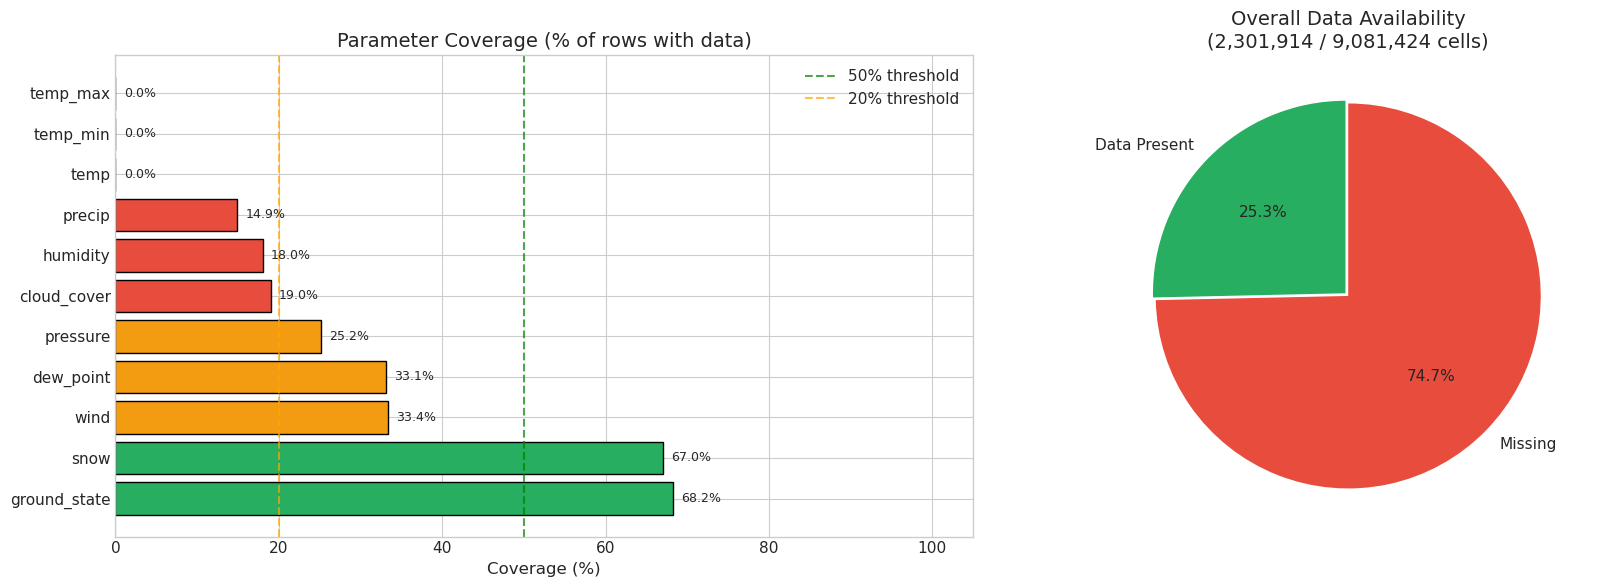

In [9]:
# Visualize parameter coverage
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart of coverage
ax = axes[0]
colors = ['#27ae60' if x >= 50 else '#f39c12' if x >= 20 else '#e74c3c' 
          for x in coverage_df['Coverage %']]
bars = ax.barh(coverage_df['Parameter'], coverage_df['Coverage %'], color=colors, edgecolor='black')
ax.set_xlabel('Coverage (%)')
ax.set_title('Parameter Coverage (% of rows with data)')
ax.axvline(x=50, color='green', linestyle='--', alpha=0.7, label='50% threshold')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='20% threshold')
ax.legend()
ax.set_xlim(0, 105)

# Add value labels
for bar, val in zip(bars, coverage_df['Coverage %']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
            va='center', fontsize=9)

# Pie chart of overall data availability
ax = axes[1]
total_cells = len(df) * len(PARAM_COLS)
non_null_cells = df[PARAM_COLS].notna().sum().sum()
null_cells = total_cells - non_null_cells

ax.pie([non_null_cells, null_cells], labels=['Data Present', 'Missing'], 
       autopct='%1.1f%%', colors=['#27ae60', '#e74c3c'],
       explode=[0.02, 0], startangle=90)
ax.set_title(f'Overall Data Availability\n({non_null_cells:,} / {total_cells:,} cells)')

plt.tight_layout()
plt.show()

In [10]:
# Categorize parameters by coverage quality
print("\n" + "=" * 100)
print("PARAMETER CATEGORIES BY COVERAGE")
print("=" * 100)

high_coverage = coverage_df[coverage_df['Coverage %'] >= 50]['Parameter'].tolist()
medium_coverage = coverage_df[(coverage_df['Coverage %'] >= 20) & (coverage_df['Coverage %'] < 50)]['Parameter'].tolist()
low_coverage = coverage_df[coverage_df['Coverage %'] < 20]['Parameter'].tolist()

print(f"\n✅ HIGH COVERAGE (≥50%): {len(high_coverage)} parameters")
for p in high_coverage:
    pct = coverage_df[coverage_df['Parameter'] == p]['Coverage %'].values[0]
    print(f"   • {p}: {pct:.1f}%")

print(f"\n⚠️ MEDIUM COVERAGE (20-50%): {len(medium_coverage)} parameters")
for p in medium_coverage:
    pct = coverage_df[coverage_df['Parameter'] == p]['Coverage %'].values[0]
    print(f"   • {p}: {pct:.1f}%")

print(f"\n❌ LOW COVERAGE (<20%): {len(low_coverage)} parameters")
for p in low_coverage:
    pct = coverage_df[coverage_df['Parameter'] == p]['Coverage %'].values[0]
    print(f"   • {p}: {pct:.1f}%")


PARAMETER CATEGORIES BY COVERAGE

✅ HIGH COVERAGE (≥50%): 2 parameters
   • ground_state: 68.2%
   • snow: 67.0%

⚠️ MEDIUM COVERAGE (20-50%): 3 parameters
   • wind: 33.4%
   • dew_point: 33.1%
   • pressure: 25.2%

❌ LOW COVERAGE (<20%): 6 parameters
   • cloud_cover: 19.0%
   • humidity: 18.0%
   • precip: 14.9%
   • temp: 0.0%
   • temp_min: 0.0%
   • temp_max: 0.0%


---
# Part 4: Station Analysis

Let's understand the geographic distribution and data availability across stations. This helps identify which stations have the best data for model training.

In [11]:
# Station summary statistics
print("=" * 100)
print("STATION SUMMARY")
print("=" * 100)

station_stats = df.groupby(['station_id', 'station_name']).agg({
    'date': ['min', 'max', 'count'],
    'latitude': 'first',
    'longitude': 'first',
    'elevation': 'first',
    **{col: lambda x: x.notna().sum() for col in PARAM_COLS}
}).reset_index()

# Flatten column names
station_stats.columns = ['station_id', 'station_name', 'date_min', 'date_max', 'record_count',
                          'latitude', 'longitude', 'elevation'] + [f'{col}_count' for col in PARAM_COLS]

# Calculate parameter count per station
param_count_cols = [f'{col}_count' for col in PARAM_COLS]
station_stats['params_with_data'] = (station_stats[param_count_cols] > 0).sum(axis=1)

# Calculate overall data coverage per station
total_param_records = station_stats[param_count_cols].sum(axis=1)
max_possible = station_stats['record_count'] * len(PARAM_COLS)
station_stats['data_coverage_pct'] = (total_param_records / max_possible * 100).round(1)

print(f"\nTotal stations: {len(station_stats)}")
print(f"Average records per station: {station_stats['record_count'].mean():.0f}")
print(f"Total records: {station_stats['record_count'].sum():,}")

STATION SUMMARY

Total stations: 271
Average records per station: 3046
Total records: 825,584


In [12]:
# Top stations by data coverage
print("\n" + "=" * 100)
print("TOP 20 STATIONS BY DATA COVERAGE")
print("=" * 100)

top_stations = station_stats.nlargest(20, 'data_coverage_pct')[[
    'station_name', 'station_id', 'record_count', 'params_with_data', 
    'data_coverage_pct', 'latitude', 'longitude', 'elevation'
]]

display(top_stations.style.background_gradient(subset=['data_coverage_pct'], cmap='RdYlGn', vmin=0, vmax=100))


TOP 20 STATIONS BY DATA COVERAGE


,station_name,station_id,record_count,params_with_data,data_coverage_pct,latitude,longitude,elevation
99,Norrköping-SMHI,86340,3927,8,65.200000,58.582800,16.147000,40.334000
265,Abisko Aut,188790,2543,8,56.600000,68.353800,18.816400,392.235000
241,Arjeplog A,167710,3911,8,54.000000,66.051300,17.839600,430.839000
173,Kuggören,117430,3927,6,53.800000,61.702700,17.522500,2.000000
91,Linköping-Malmslätt,85240,3927,7,53.700000,58.398000,15.523000,94.000000
226,Arvidsjaur,159880,3886,6,53.600000,65.585300,19.185200,385.000000
39,Vinga,71380,3927,6,53.400000,57.632200,11.606100,19.000000
163,Örskär A,108320,3924,6,53.400000,60.525600,18.372900,6.539000
121,Flodafors,96040,3927,6,52.900000,59.066600,16.366600,50.000000
195,Krångede,136090,3927,6,52.900000,63.161000,16.171800,220.000000


In [13]:
# Stations with poor coverage (bottom 20)
print("\n" + "=" * 100)
print("BOTTOM 20 STATIONS BY DATA COVERAGE")
print("=" * 100)

bottom_stations = station_stats.nsmallest(20, 'data_coverage_pct')[[
    'station_name', 'station_id', 'record_count', 'params_with_data', 
    'data_coverage_pct', 'latitude', 'longitude', 'elevation'
]]

display(bottom_stations.style.background_gradient(subset=['data_coverage_pct'], cmap='RdYlGn', vmin=0, vmax=100))


BOTTOM 20 STATIONS BY DATA COVERAGE


,station_name,station_id,record_count,params_with_data,data_coverage_pct,latitude,longitude,elevation
70,Fårö,79580,30,1,9.100000,57.898700,19.159200,8.000000
111,Villingsberg,94170,1,1,9.100000,59.283000,14.690200,153.000000
162,Risinge,108110,2,1,9.100000,60.174800,18.224000,17.210000
147,Venjan,103570,134,2,12.600000,60.941700,13.897700,278.000000
207,Jormlien,143440,102,2,12.700000,64.729100,13.981900,383.088000
187,Edevik,132590,788,2,13.300000,63.980100,12.868700,412.000000
193,Almdalen,134590,3603,2,13.300000,63.996700,14.670100,615.000000
259,Svappavaara,181890,2914,2,13.400000,67.652900,21.047200,358.000000
166,Trängslet,113230,320,2,14.100000,61.379500,13.723500,419.000000
190,Järpströmmen,133240,2881,2,14.300000,63.390300,13.384500,386.652000


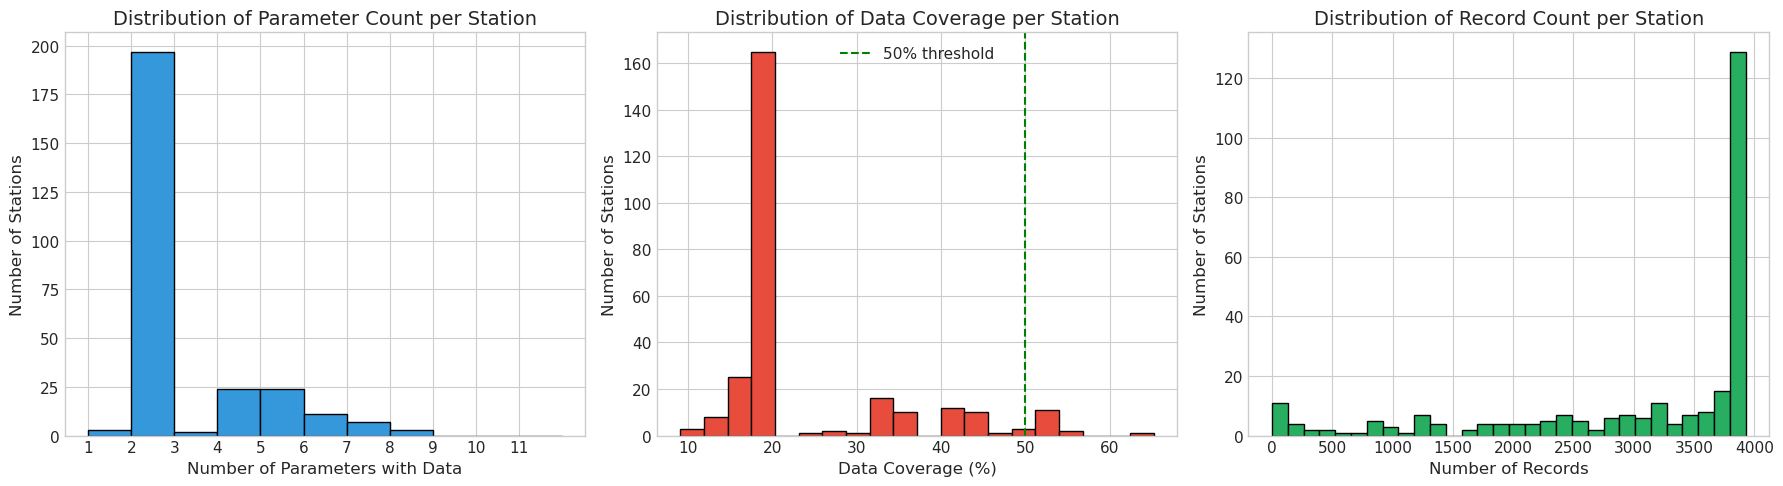

In [14]:
# Distribution of stations by parameter count
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of parameters per station
ax = axes[0]
ax.hist(station_stats['params_with_data'], bins=range(1, 13), edgecolor='black', color=COLORS['primary'])
ax.set_xlabel('Number of Parameters with Data')
ax.set_ylabel('Number of Stations')
ax.set_title('Distribution of Parameter Count per Station')
ax.set_xticks(range(1, 12))

# Histogram of data coverage
ax = axes[1]
ax.hist(station_stats['data_coverage_pct'], bins=20, edgecolor='black', color=COLORS['secondary'])
ax.set_xlabel('Data Coverage (%)')
ax.set_ylabel('Number of Stations')
ax.set_title('Distribution of Data Coverage per Station')
ax.axvline(x=50, color='green', linestyle='--', label='50% threshold')
ax.legend()

# Histogram of record counts
ax = axes[2]
ax.hist(station_stats['record_count'], bins=30, edgecolor='black', color=COLORS['success'])
ax.set_xlabel('Number of Records')
ax.set_ylabel('Number of Stations')
ax.set_title('Distribution of Record Count per Station')

plt.tight_layout()
plt.show()

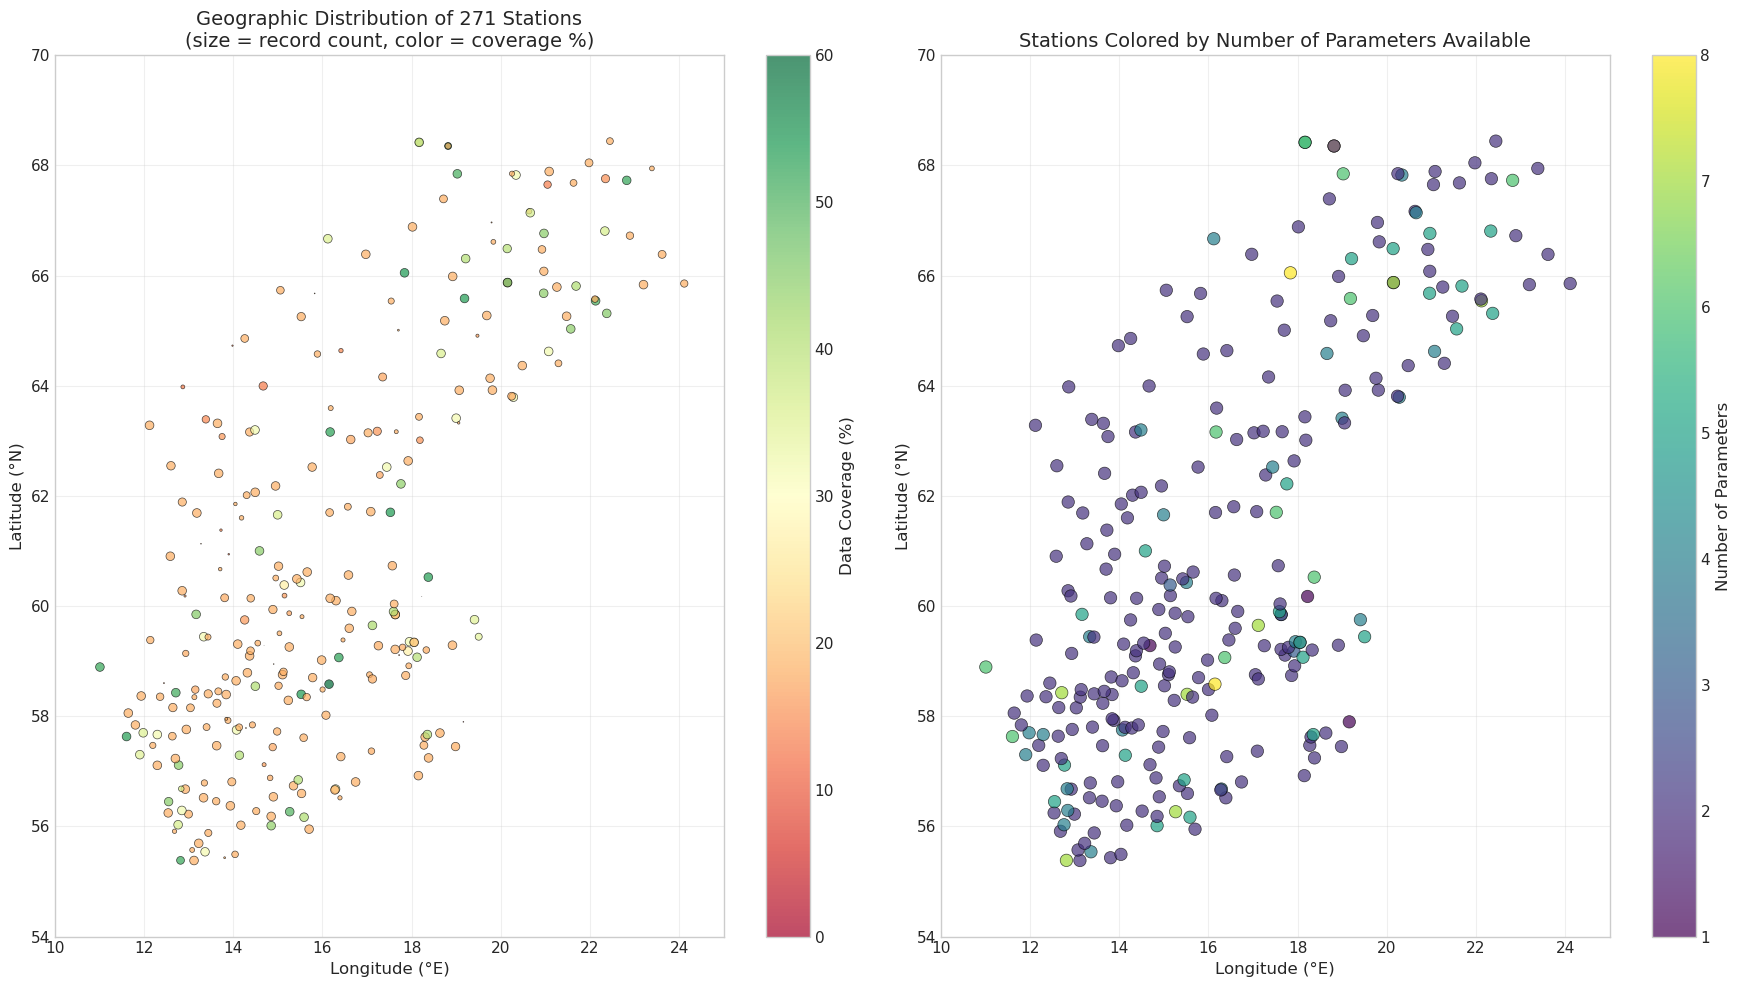

In [15]:
# Geographic distribution of stations
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# All stations colored by data coverage
ax = axes[0]
scatter = ax.scatter(station_stats['longitude'], station_stats['latitude'],
                    c=station_stats['data_coverage_pct'], cmap='RdYlGn',
                    s=station_stats['record_count']/100, alpha=0.7,
                    edgecolors='black', linewidth=0.5, vmin=0, vmax=60)
plt.colorbar(scatter, ax=ax, label='Data Coverage (%)')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(f'Geographic Distribution of {len(station_stats)} Stations\n(size = record count, color = coverage %)')
ax.set_xlim(10, 25)
ax.set_ylim(54, 70)
ax.grid(True, alpha=0.3)

# Stations colored by number of parameters
ax = axes[1]
scatter = ax.scatter(station_stats['longitude'], station_stats['latitude'],
                    c=station_stats['params_with_data'], cmap='viridis',
                    s=80, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, ax=ax, label='Number of Parameters')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title('Stations Colored by Number of Parameters Available')
ax.set_xlim(10, 25)
ax.set_ylim(54, 70)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

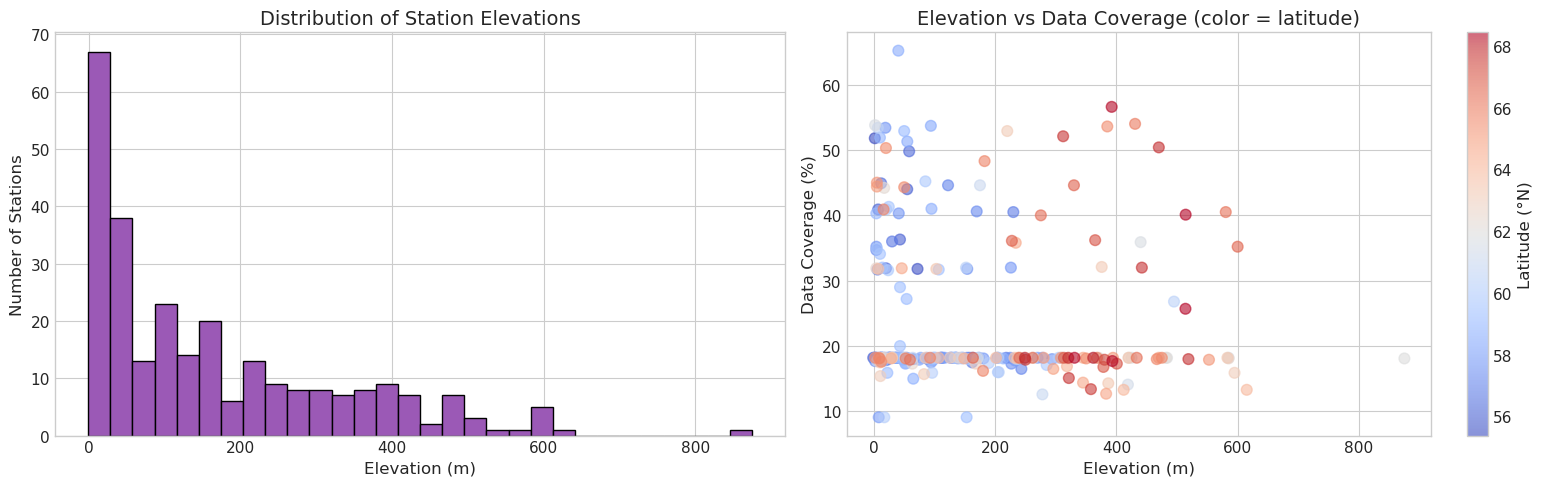


Elevation range: -1m to 875m
Mean elevation: 164m
Median elevation: 107m


In [16]:
# Elevation distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of elevations
ax = axes[0]
ax.hist(station_stats['elevation'], bins=30, edgecolor='black', color=COLORS['info'])
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Number of Stations')
ax.set_title('Distribution of Station Elevations')

# Elevation vs data coverage
ax = axes[1]
ax.scatter(station_stats['elevation'], station_stats['data_coverage_pct'],
          c=station_stats['latitude'], cmap='coolwarm', s=60, alpha=0.6)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Data Coverage (%)')
ax.set_title('Elevation vs Data Coverage (color = latitude)')
plt.colorbar(ax.collections[0], ax=ax, label='Latitude (°N)')

plt.tight_layout()
plt.show()

print(f"\nElevation range: {station_stats['elevation'].min():.0f}m to {station_stats['elevation'].max():.0f}m")
print(f"Mean elevation: {station_stats['elevation'].mean():.0f}m")
print(f"Median elevation: {station_stats['elevation'].median():.0f}m")

---
# Part 5: Temporal Analysis

Understanding how data availability changes over time is crucial for training/validation splits and identifying data gaps.

In [17]:
# Add temporal columns
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['season'] = df['month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                 3: 'Spring', 4: 'Spring', 5: 'Spring',
                                 6: 'Summer', 7: 'Summer', 8: 'Summer',
                                 9: 'Autumn', 10: 'Autumn', 11: 'Autumn'})

print("Temporal columns added: year, month, day_of_year, season")

Temporal columns added: year, month, day_of_year, season


In [18]:
# Records per year
print("=" * 100)
print("RECORDS PER YEAR")
print("=" * 100)

yearly_stats = df.groupby('year').agg({
    'station_id': 'count',
    'station_name': 'nunique',
    **{col: lambda x: x.notna().sum() for col in PARAM_COLS}
}).reset_index()

yearly_stats.columns = ['Year', 'Records', 'Stations'] + [f'{col}_count' for col in PARAM_COLS]

display(yearly_stats[['Year', 'Records', 'Stations']])

RECORDS PER YEAR


,Year,Records,Stations
0,2015,75781,238
1,2016,76178,241
2,2017,76996,240
3,2018,75689,242
4,2019,75384,232
5,2020,78704,235
6,2021,80601,236
7,2022,78257,229
8,2023,75845,222
9,2024,75351,220


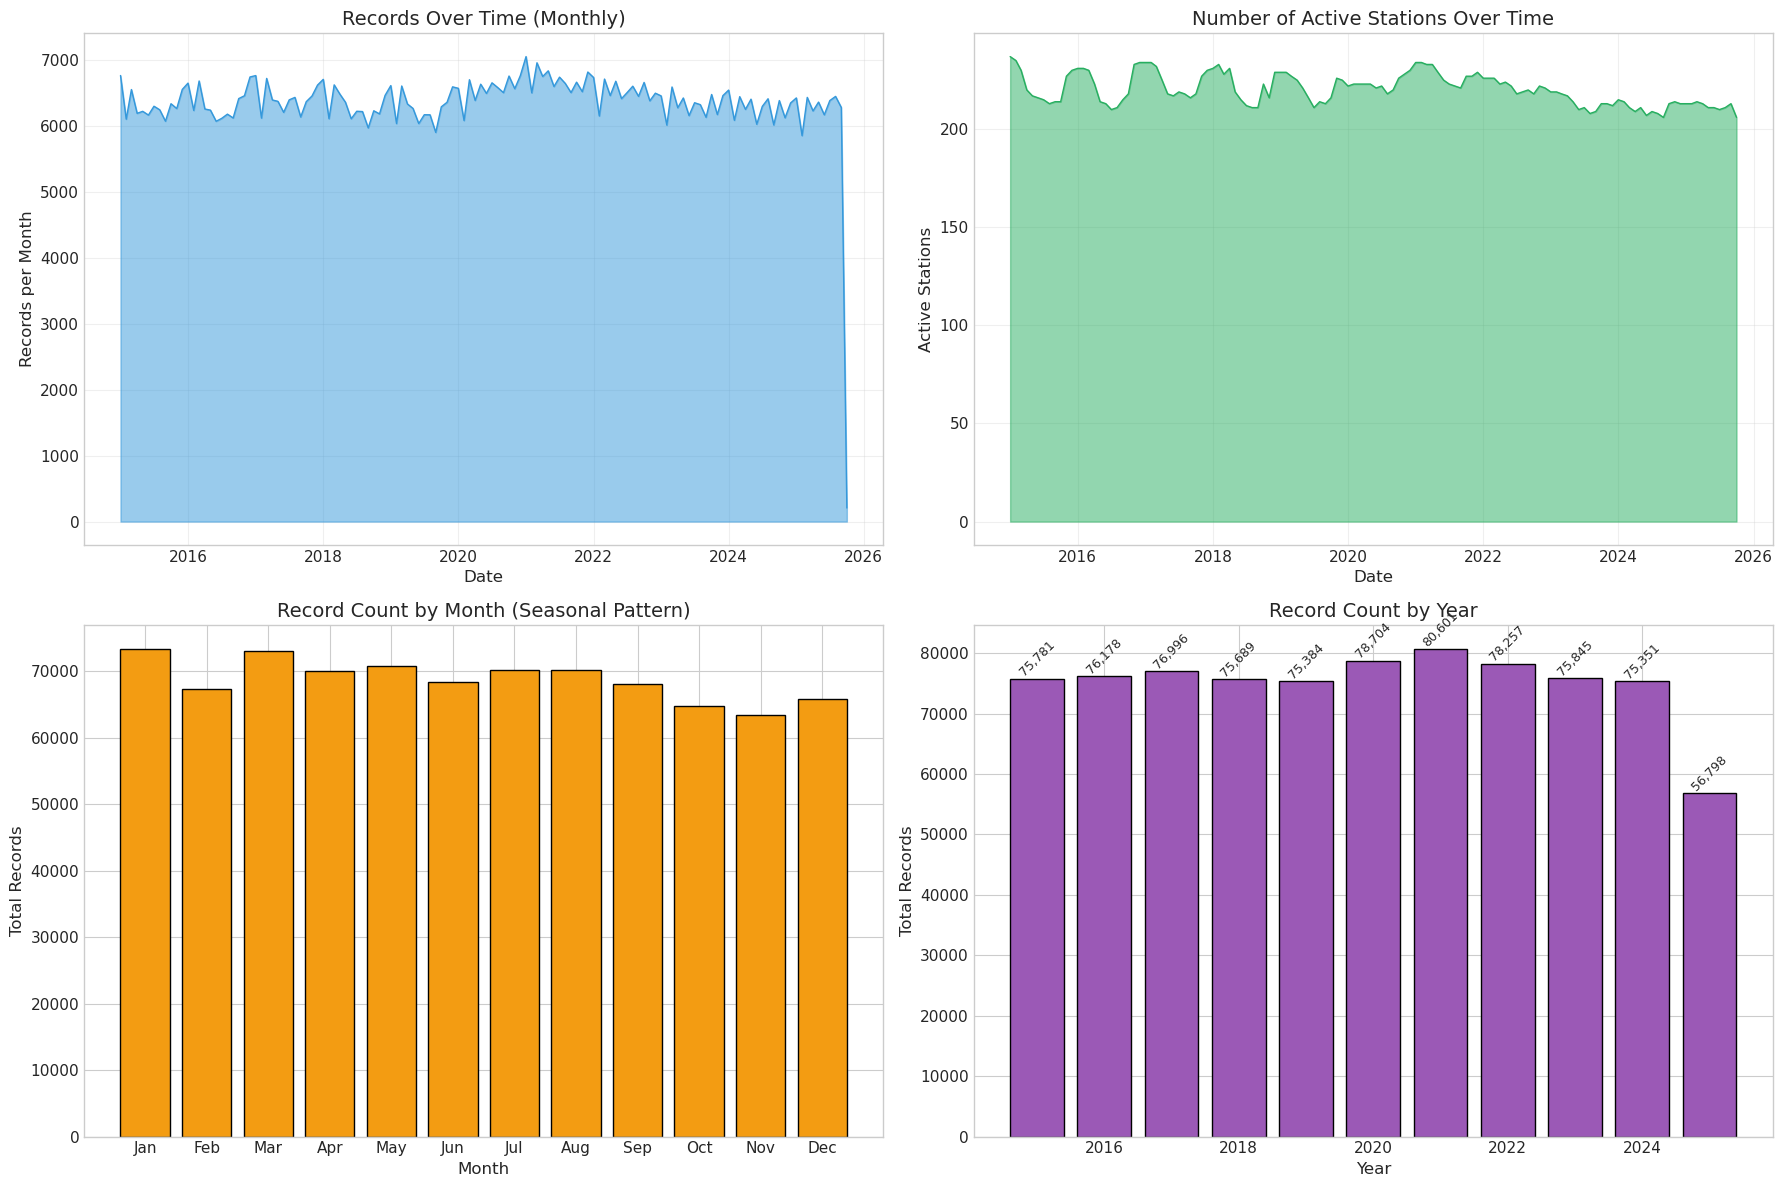

In [19]:
# Visualize temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Records over time (monthly)
ax = axes[0, 0]
monthly_records = df.groupby(df['date'].dt.to_period('M')).size()
monthly_records.index = monthly_records.index.to_timestamp()
ax.fill_between(monthly_records.index, monthly_records.values, alpha=0.5, color=COLORS['primary'])
ax.plot(monthly_records.index, monthly_records.values, color=COLORS['primary'], linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Records per Month')
ax.set_title('Records Over Time (Monthly)')
ax.grid(True, alpha=0.3)

# Active stations over time
ax = axes[0, 1]
monthly_stations = df.groupby(df['date'].dt.to_period('M'))['station_id'].nunique()
monthly_stations.index = monthly_stations.index.to_timestamp()
ax.fill_between(monthly_stations.index, monthly_stations.values, alpha=0.5, color=COLORS['success'])
ax.plot(monthly_stations.index, monthly_stations.values, color=COLORS['success'], linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Active Stations')
ax.set_title('Number of Active Stations Over Time')
ax.grid(True, alpha=0.3)

# Records by month (seasonality)
ax = axes[1, 0]
monthly_avg = df.groupby('month').size()
bars = ax.bar(monthly_avg.index, monthly_avg.values, color=COLORS['warning'], edgecolor='black')
ax.set_xlabel('Month')
ax.set_ylabel('Total Records')
ax.set_title('Record Count by Month (Seasonal Pattern)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Records by year
ax = axes[1, 1]
yearly_records = df.groupby('year').size()
bars = ax.bar(yearly_records.index, yearly_records.values, color=COLORS['info'], edgecolor='black')
ax.set_xlabel('Year')
ax.set_ylabel('Total Records')
ax.set_title('Record Count by Year')
for bar, val in zip(bars, yearly_records.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:,}', 
            ha='center', va='bottom', fontsize=9, rotation=45)

plt.tight_layout()
plt.show()

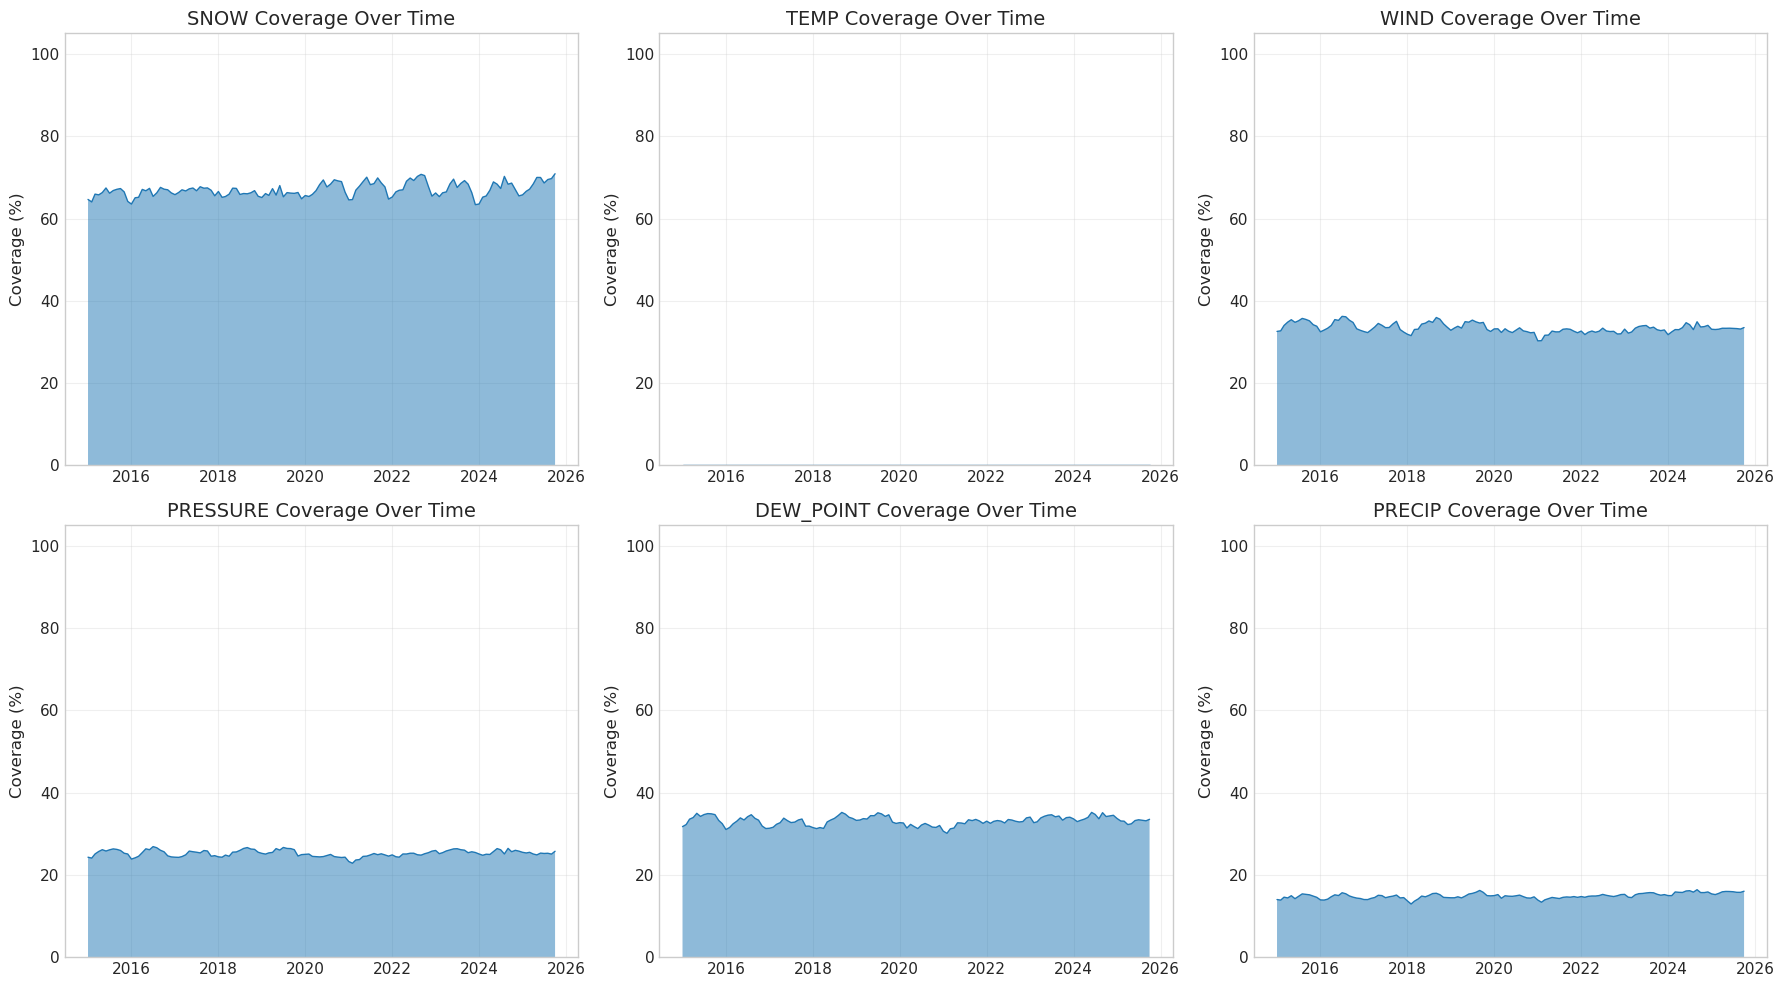

In [20]:
# Parameter coverage over time
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

key_params = ['snow', 'temp', 'wind', 'pressure', 'dew_point', 'precip']

for ax, param in zip(axes.flatten(), key_params):
    if param in df.columns:
        monthly_coverage = df.groupby(df['date'].dt.to_period('M'))[param].apply(
            lambda x: x.notna().sum() / len(x) * 100 if len(x) > 0 else 0
        )
        monthly_coverage.index = monthly_coverage.index.to_timestamp()
        
        ax.fill_between(monthly_coverage.index, monthly_coverage.values, alpha=0.5)
        ax.plot(monthly_coverage.index, monthly_coverage.values, linewidth=1)
        ax.set_ylabel('Coverage (%)')
        ax.set_title(f'{param.upper()} Coverage Over Time')
        ax.set_ylim(0, 105)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part 6: Snow Depth Analysis (Primary Target)

Snow depth is our primary target variable. Let's analyze it in detail.

In [21]:
# Snow depth statistics
print("=" * 100)
print("SNOW DEPTH STATISTICS")
print("=" * 100)

snow_data = df['snow'].dropna()
snow_cm = snow_data * 100  # Convert m to cm for readability

stats = {
    'Total records': len(df),
    'Records with snow data': len(snow_data),
    'Coverage': f"{len(snow_data)/len(df)*100:.1f}%",
    'Mean (cm)': f"{snow_cm.mean():.2f}",
    'Median (cm)': f"{snow_cm.median():.2f}",
    'Std (cm)': f"{snow_cm.std():.2f}",
    'Min (cm)': f"{snow_cm.min():.2f}",
    'Max (cm)': f"{snow_cm.max():.2f}",
    'Zero snow records': f"{(snow_data == 0).sum():,} ({(snow_data == 0).sum()/len(snow_data)*100:.1f}%)",
    'Non-zero snow records': f"{(snow_data > 0).sum():,} ({(snow_data > 0).sum()/len(snow_data)*100:.1f}%)",
    'Negative values': (snow_data < 0).sum(),
}

for key, value in stats.items():
    print(f"  {key:<30}: {value}")

SNOW DEPTH STATISTICS
  Total records                 : 825584
  Records with snow data        : 553042
  Coverage                      : 67.0%
  Mean (cm)                     : 8.41
  Median (cm)                   : 0.00
  Std (cm)                      : 21.17
  Min (cm)                      : -2.00
  Max (cm)                      : 229.00
  Zero snow records             : 417,847 (75.6%)
  Non-zero snow records         : 134,825 (24.4%)
  Negative values               : 370


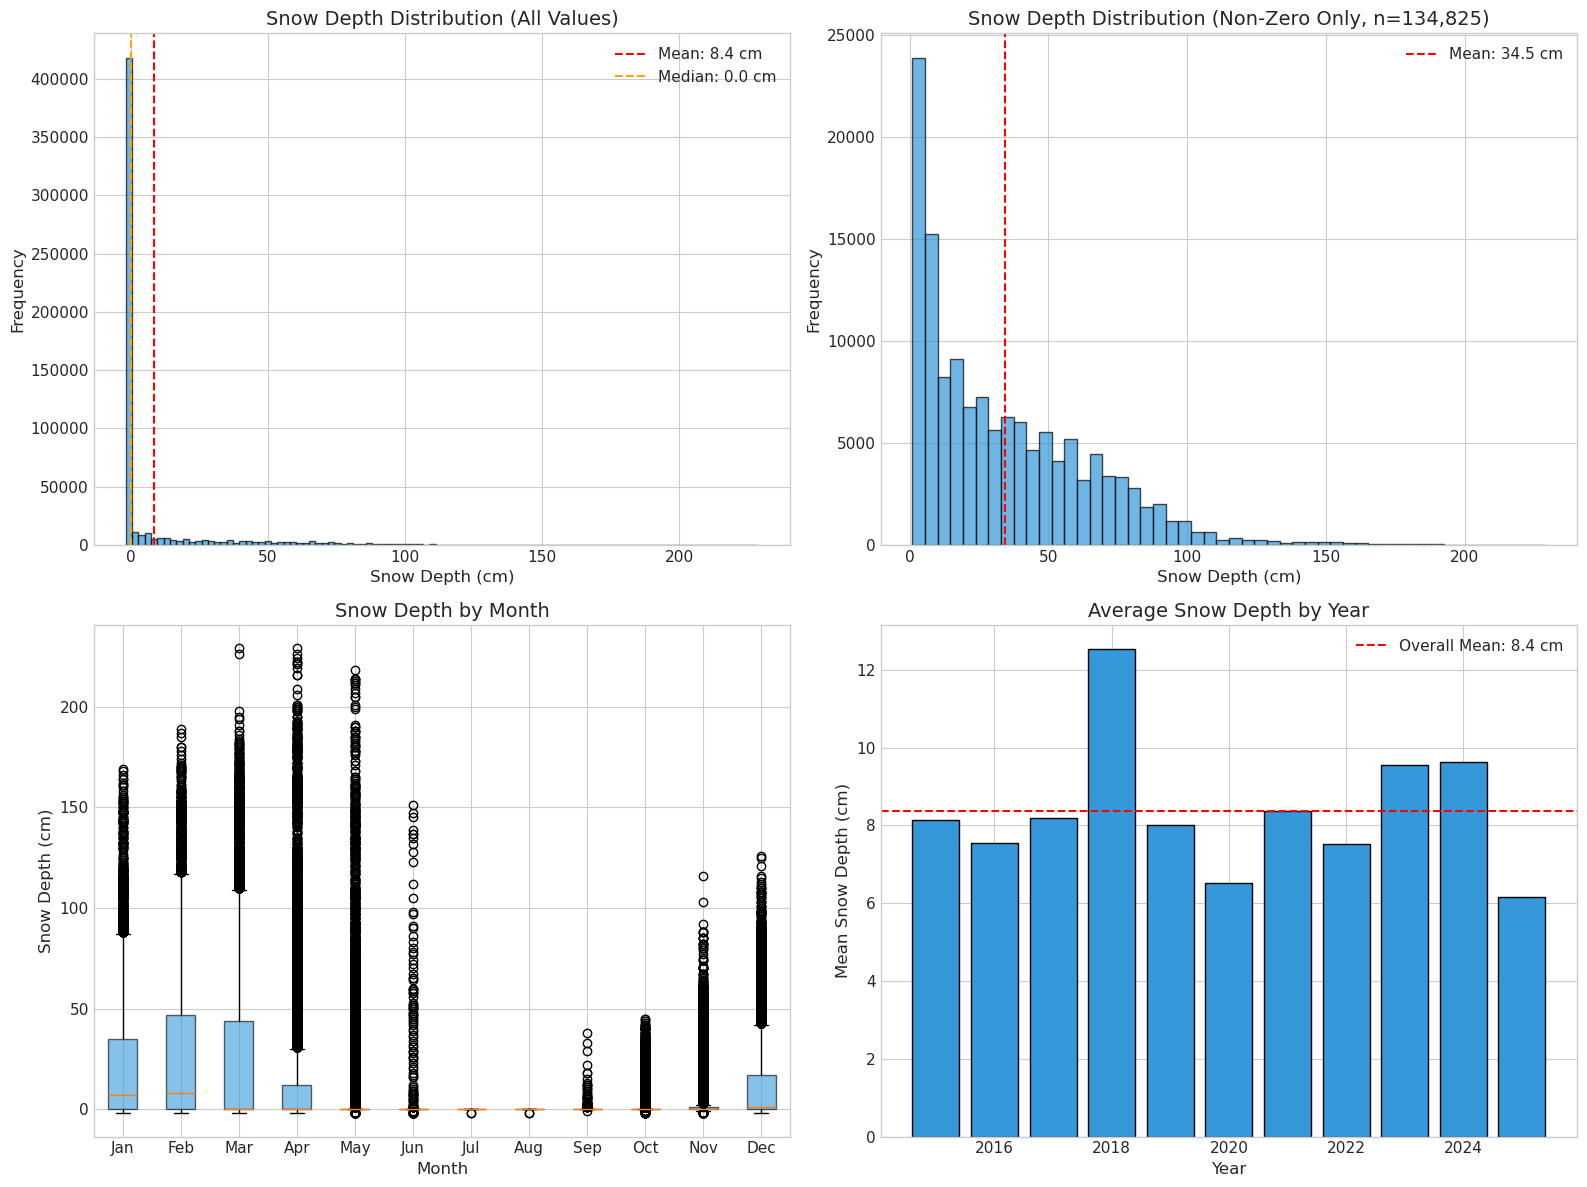

In [22]:
# Snow depth distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram of all snow values
ax = axes[0, 0]
ax.hist(snow_cm, bins=100, edgecolor='black', color=COLORS['snow'], alpha=0.7)
ax.set_xlabel('Snow Depth (cm)')
ax.set_ylabel('Frequency')
ax.set_title('Snow Depth Distribution (All Values)')
ax.axvline(x=snow_cm.mean(), color='red', linestyle='--', label=f'Mean: {snow_cm.mean():.1f} cm')
ax.axvline(x=snow_cm.median(), color='orange', linestyle='--', label=f'Median: {snow_cm.median():.1f} cm')
ax.legend()

# Histogram of non-zero snow values
ax = axes[0, 1]
non_zero_snow = snow_cm[snow_cm > 0]
ax.hist(non_zero_snow, bins=50, edgecolor='black', color=COLORS['snow'], alpha=0.7)
ax.set_xlabel('Snow Depth (cm)')
ax.set_ylabel('Frequency')
ax.set_title(f'Snow Depth Distribution (Non-Zero Only, n={len(non_zero_snow):,})')
ax.axvline(x=non_zero_snow.mean(), color='red', linestyle='--', label=f'Mean: {non_zero_snow.mean():.1f} cm')
ax.legend()

# Box plot by month
ax = axes[1, 0]
snow_by_month = [df[df['month'] == m]['snow'].dropna() * 100 for m in range(1, 13)]
bp = ax.boxplot(snow_by_month, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor(COLORS['snow'])
    patch.set_alpha(0.6)
ax.set_xlabel('Month')
ax.set_ylabel('Snow Depth (cm)')
ax.set_title('Snow Depth by Month')
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Mean snow by year
ax = axes[1, 1]
yearly_snow = df.groupby('year')['snow'].mean() * 100
ax.bar(yearly_snow.index, yearly_snow.values, color=COLORS['snow'], edgecolor='black')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Snow Depth (cm)')
ax.set_title('Average Snow Depth by Year')
ax.axhline(y=yearly_snow.mean(), color='red', linestyle='--', label=f'Overall Mean: {yearly_snow.mean():.1f} cm')
ax.legend()

plt.tight_layout()
plt.show()

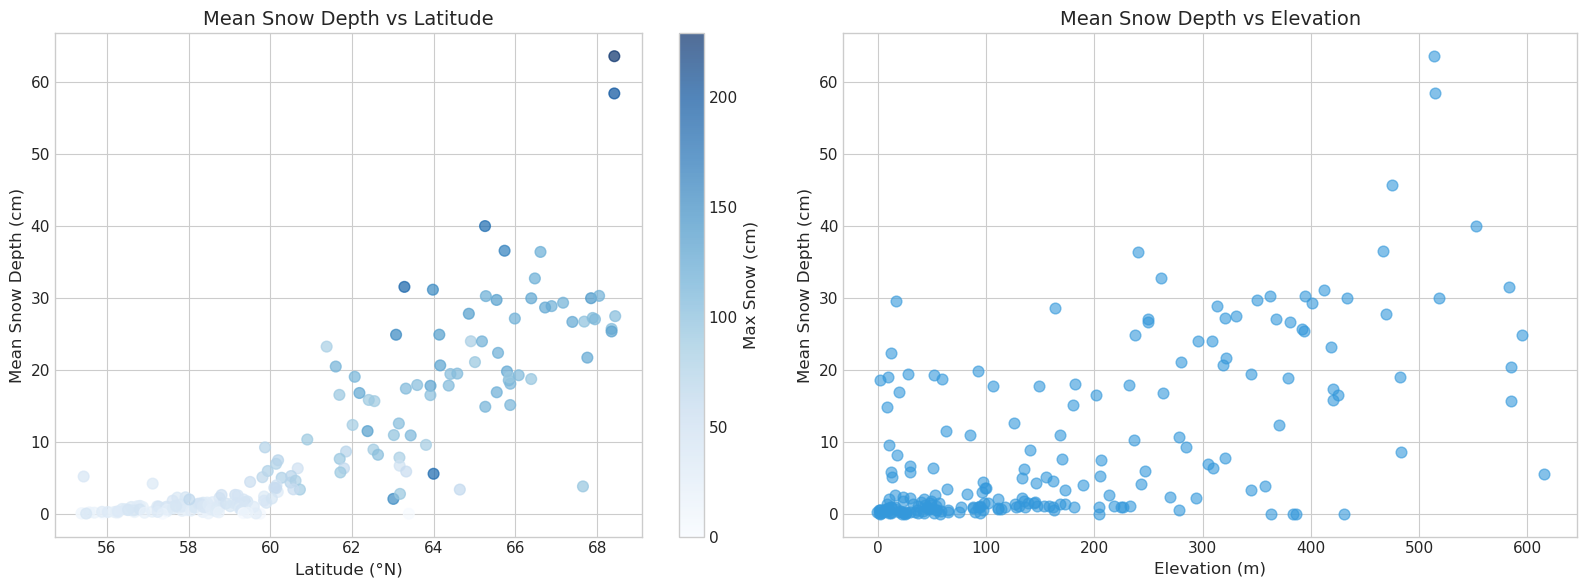

In [23]:
# Snow by latitude (geographic pattern)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: latitude vs mean snow
ax = axes[0]
station_snow = df.groupby(['station_id', 'station_name', 'latitude']).agg({
    'snow': ['mean', 'max', 'count']
}).reset_index()
station_snow.columns = ['station_id', 'station_name', 'latitude', 'mean_snow', 'max_snow', 'count']
station_snow['mean_snow_cm'] = station_snow['mean_snow'] * 100
station_snow['max_snow_cm'] = station_snow['max_snow'] * 100

# Only include stations with significant snow data
station_snow_valid = station_snow[station_snow['count'] > 100]

scatter = ax.scatter(station_snow_valid['latitude'], station_snow_valid['mean_snow_cm'],
                    c=station_snow_valid['max_snow_cm'], cmap='Blues', s=60, alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Max Snow (cm)')
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Mean Snow Depth (cm)')
ax.set_title('Mean Snow Depth vs Latitude')

# Scatter plot: elevation vs mean snow
ax = axes[1]
station_elev = df.groupby(['station_id', 'station_name', 'elevation']).agg({
    'snow': ['mean', 'max']
}).reset_index()
station_elev.columns = ['station_id', 'station_name', 'elevation', 'mean_snow', 'max_snow']
station_elev['mean_snow_cm'] = station_elev['mean_snow'] * 100

ax.scatter(station_elev['elevation'], station_elev['mean_snow_cm'], 
          c=COLORS['snow'], s=60, alpha=0.6)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Mean Snow Depth (cm)')
ax.set_title('Mean Snow Depth vs Elevation')

plt.tight_layout()
plt.show()

---
# Part 7: Parameter Relationships & Correlations

Understanding how parameters relate to each other helps in feature selection and model design.

PARAMETER CORRELATIONS


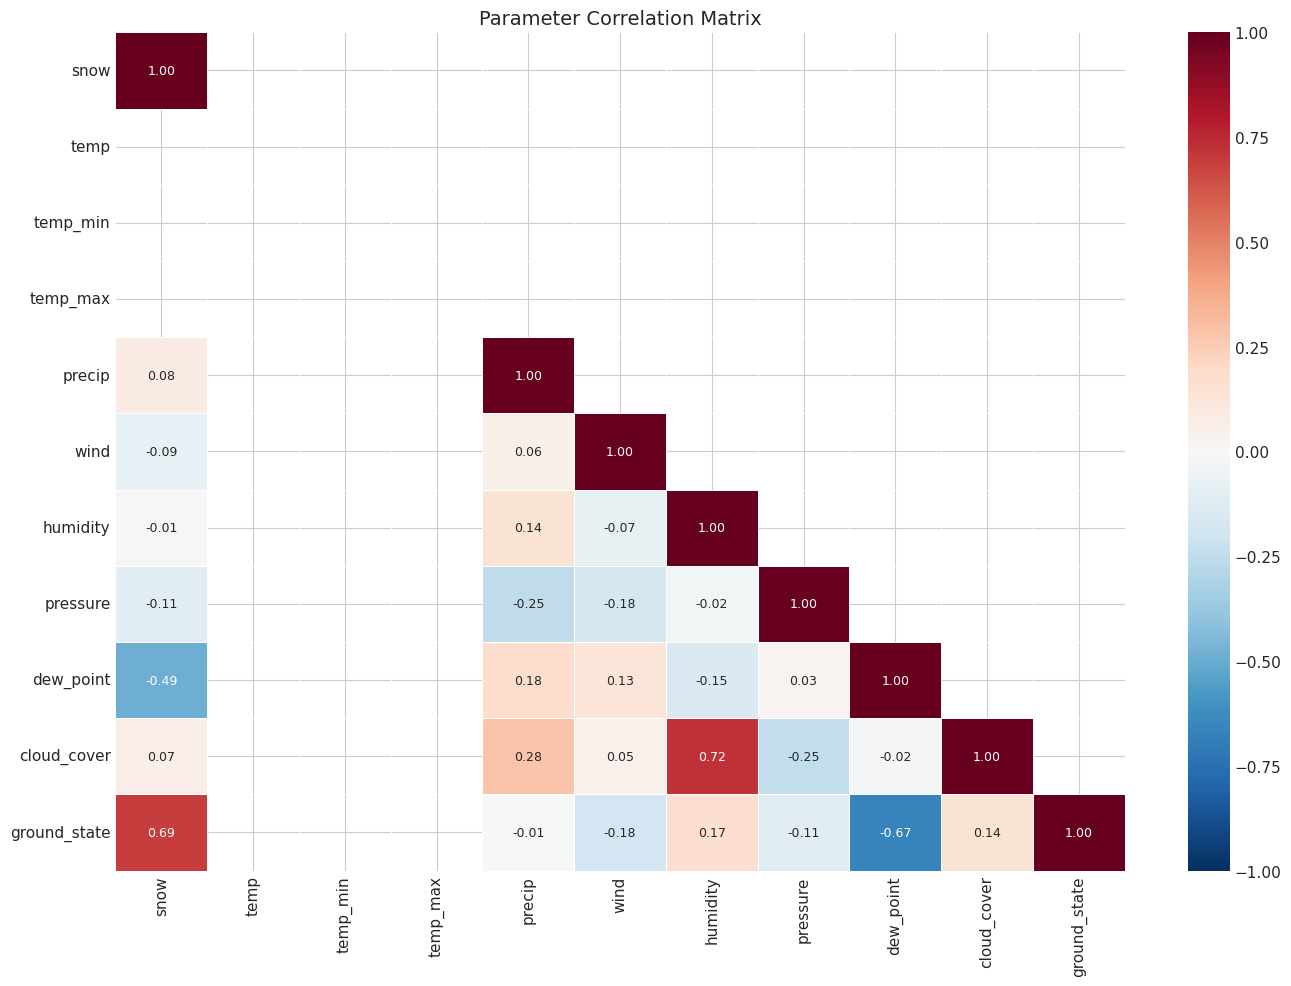

In [24]:
# Correlation matrix
print("=" * 100)
print("PARAMETER CORRELATIONS")
print("=" * 100)

# Calculate correlations (only for rows with data)
corr_matrix = df[PARAM_COLS].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Parameter Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# Key correlations with snow
print("\nCorrelations with SNOW:")
snow_corr = corr_matrix['snow'].drop('snow').sort_values(key=abs, ascending=False)
for param, corr in snow_corr.items():
    if not np.isnan(corr):
        direction = '↑' if corr > 0 else '↓'
        strength = 'Strong' if abs(corr) > 0.5 else 'Moderate' if abs(corr) > 0.3 else 'Weak'
        print(f"  {param:<15}: {corr:>6.3f} {direction} ({strength})")


Correlations with SNOW:
  ground_state   :  0.688 ↑ (Strong)
  dew_point      : -0.487 ↓ (Moderate)
  pressure       : -0.113 ↓ (Weak)
  wind           : -0.085 ↓ (Weak)
  precip         :  0.084 ↑ (Weak)
  cloud_cover    :  0.068 ↑ (Weak)
  humidity       : -0.009 ↓ (Weak)


ValueError: a must be greater than 0 unless no samples are taken

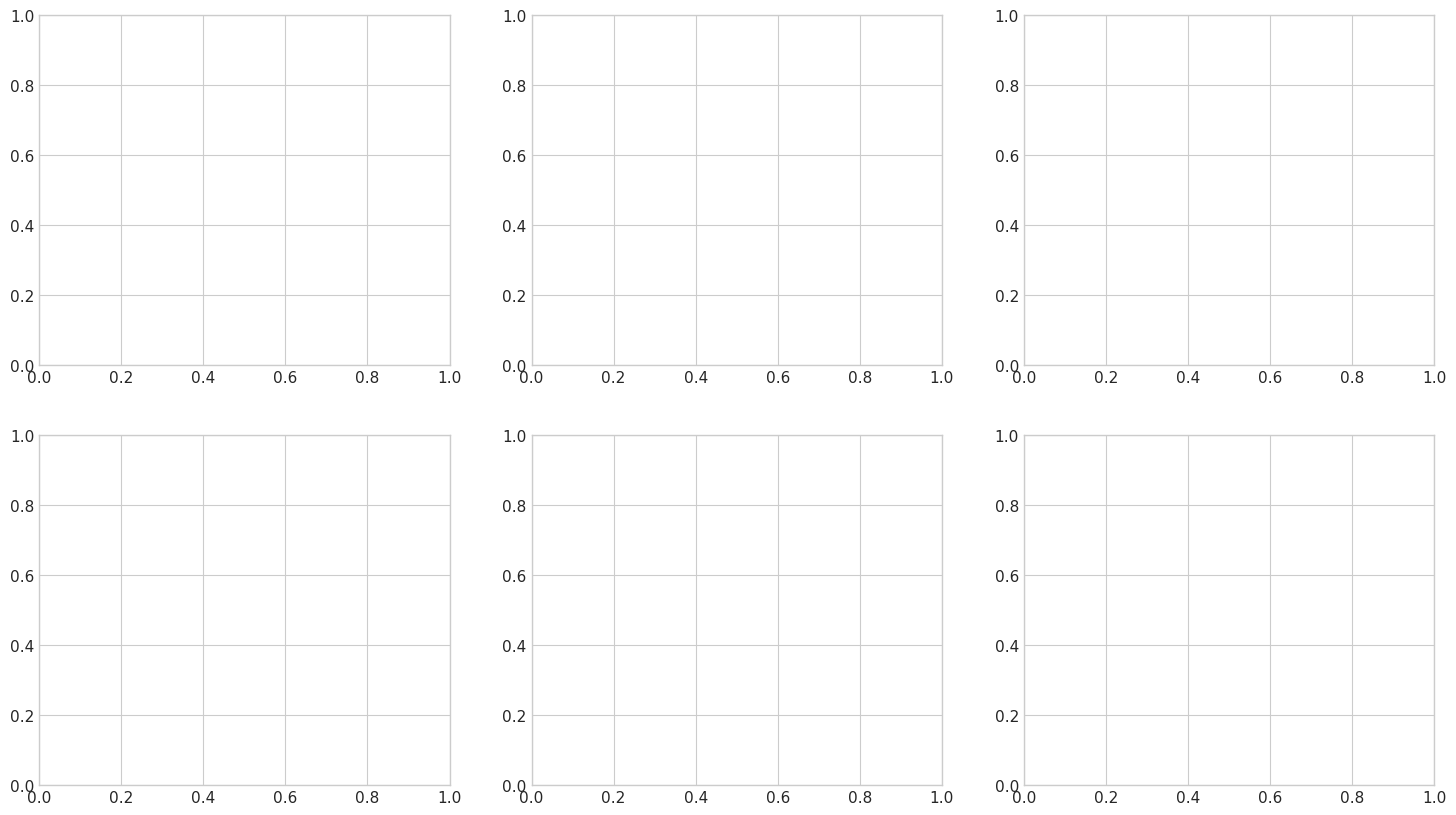

In [26]:
# Scatter plots of key relationships
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

relationships = [
    ('temp', 'snow', 'Temperature vs Snow'),
    ('dew_point', 'snow', 'Dew Point vs Snow'),
    ('precip', 'snow', 'Precipitation vs Snow'),
    ('temp', 'dew_point', 'Temperature vs Dew Point'),
    ('pressure', 'snow', 'Pressure vs Snow'),
    ('wind', 'snow', 'Wind vs Snow'),
]

for ax, (x_param, y_param, title) in zip(axes.flatten(), relationships):
    if x_param in df.columns and y_param in df.columns:
        # Sample for performance
        sample = df[[x_param, y_param]].dropna().sample(min(10000, len(df)), random_state=42)
        
        y_vals = sample[y_param] * 100 if y_param == 'snow' else sample[y_param]
        
        ax.scatter(sample[x_param], y_vals, alpha=0.3, s=10)
        ax.set_xlabel(x_param)
        ax.set_ylabel(f'{y_param}' + (' (cm)' if y_param == 'snow' else ''))
        ax.set_title(title)
        
        # Add correlation
        corr = df[[x_param, y_param]].corr().iloc[0, 1]
        ax.text(0.95, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
               ha='right', va='top', fontsize=10, 
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

---
# Part 8: Data Quality Assessment

Identifying data quality issues is crucial before model training.

In [27]:
# Check for anomalies and quality issues
print("=" * 100)
print("DATA QUALITY ASSESSMENT")
print("=" * 100)

quality_issues = []

# 1. Duplicate rows
duplicates = df.duplicated(subset=['station_id', 'date']).sum()
quality_issues.append(('Duplicate (station_id, date) pairs', duplicates))

# 2. Negative values in non-negative parameters
non_negative_params = ['snow', 'precip', 'wind', 'humidity', 'cloud_cover']
for param in non_negative_params:
    if param in df.columns:
        neg_count = (df[param] < 0).sum()
        if neg_count > 0:
            quality_issues.append((f'Negative {param} values', neg_count))

# 3. Out-of-range values
range_checks = {
    'humidity': (0, 100),
    'cloud_cover': (0, 100),
    'snow': (0, 5),  # > 5m is suspicious
    'temp': (-60, 50),  # Sweden extremes
    'wind': (0, 50),  # > 50 m/s is extreme
}

for param, (min_val, max_val) in range_checks.items():
    if param in df.columns:
        out_of_range = ((df[param] < min_val) | (df[param] > max_val)).sum()
        if out_of_range > 0:
            quality_issues.append((f'{param} out of range ({min_val}-{max_val})', out_of_range))

# 4. Missing station metadata
missing_lat = df['latitude'].isna().sum()
missing_lon = df['longitude'].isna().sum()
missing_elev = df['elevation'].isna().sum()
if missing_lat > 0:
    quality_issues.append(('Missing latitude', missing_lat))
if missing_lon > 0:
    quality_issues.append(('Missing longitude', missing_lon))
if missing_elev > 0:
    quality_issues.append(('Missing elevation', missing_elev))

print("\nQuality Issues Found:")
if quality_issues:
    for issue, count in quality_issues:
        print(f"  ⚠️ {issue}: {count:,}")
else:
    print("  ✅ No significant quality issues detected")

DATA QUALITY ASSESSMENT

Quality Issues Found:
  ⚠️ Duplicate (station_id, date) pairs: 0
  ⚠️ Negative snow values: 370
  ⚠️ Negative precip values: 5
  ⚠️ Negative humidity values: 46
  ⚠️ humidity out of range (0-100): 46
  ⚠️ cloud_cover out of range (0-100): 9,779
  ⚠️ snow out of range (0-5): 370


In [28]:
# Missing data patterns
print("\n" + "=" * 100)
print("MISSING DATA ANALYSIS")
print("=" * 100)

# Calculate missing data per row
df['missing_params'] = df[PARAM_COLS].isna().sum(axis=1)
df['available_params'] = len(PARAM_COLS) - df['missing_params']

print(f"\nDistribution of available parameters per row:")
for i in range(len(PARAM_COLS) + 1):
    count = (df['available_params'] == i).sum()
    pct = count / len(df) * 100
    if count > 0:
        print(f"  {i} parameters: {count:>10,} rows ({pct:>5.1f}%)")


MISSING DATA ANALYSIS

Distribution of available parameters per row:
  1 parameters:     18,958 rows (  2.3%)
  2 parameters:    544,210 rows ( 65.9%)
  3 parameters:     41,599 rows (  5.0%)
  4 parameters:     98,627 rows ( 11.9%)
  5 parameters:     69,322 rows (  8.4%)
  6 parameters:     44,161 rows (  5.3%)
  7 parameters:      6,001 rows (  0.7%)
  8 parameters:      2,706 rows (  0.3%)


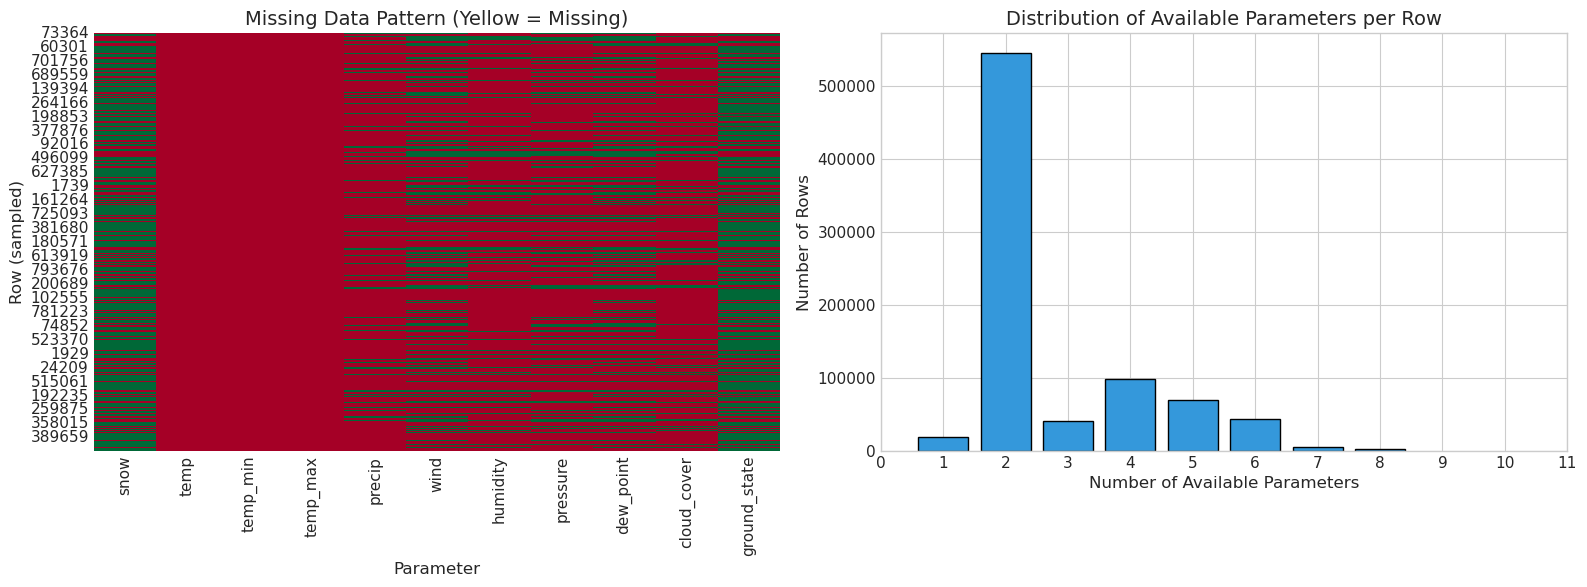

In [29]:
# Visualize missing data patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Missing data heatmap (sample for performance)
ax = axes[0]
sample_missing = df[PARAM_COLS].sample(min(5000, len(df)), random_state=42)
sns.heatmap(sample_missing.isna().astype(int), cmap='RdYlGn_r', cbar=False, ax=ax)
ax.set_xlabel('Parameter')
ax.set_ylabel('Row (sampled)')
ax.set_title('Missing Data Pattern (Yellow = Missing)')

# Distribution of available parameters
ax = axes[1]
param_dist = df['available_params'].value_counts().sort_index()
ax.bar(param_dist.index, param_dist.values, color=COLORS['primary'], edgecolor='black')
ax.set_xlabel('Number of Available Parameters')
ax.set_ylabel('Number of Rows')
ax.set_title('Distribution of Available Parameters per Row')
ax.set_xticks(range(len(PARAM_COLS) + 1))

plt.tight_layout()
plt.show()

---
# Part 9: Station-Parameter Matrix

Which stations have which parameters? This helps identify the best stations for multi-task learning.

In [30]:
# Create station-parameter coverage matrix
print("=" * 100)
print("STATION-PARAMETER COVERAGE MATRIX")
print("=" * 100)

station_param_coverage = df.groupby('station_name')[PARAM_COLS].apply(
    lambda x: (x.notna().sum() / len(x) * 100).round(1)
)

# Sort by overall coverage
station_param_coverage['total_coverage'] = station_param_coverage.mean(axis=1)
station_param_coverage = station_param_coverage.sort_values('total_coverage', ascending=False)

print(f"\nTop 15 stations by overall coverage:")
display(station_param_coverage.head(15).style.background_gradient(cmap='RdYlGn', vmin=0, vmax=100))

STATION-PARAMETER COVERAGE MATRIX

Top 15 stations by overall coverage:


,snow,temp,temp_min,temp_max,precip,wind,humidity,pressure,dew_point,cloud_cover,ground_state,total_coverage
station_name,,,,,,,,,,,,
Norrköping-SMHI,62.400000,0.000000,0.000000,0.000000,99.600000,99.900000,95.300000,100.000000,100.000000,98.100000,62.400000,65.245455
Abisko Aut,48.100000,0.000000,0.000000,0.000000,92.600000,99.900000,84.400000,99.700000,99.500000,85.300000,13.400000,56.627273
Arjeplog A,0.000000,0.000000,0.000000,0.000000,97.000000,98.900000,98.500000,100.000000,99.800000,99.700000,0.000000,53.990909
Kuggören,0.000000,0.000000,0.000000,0.000000,99.900000,100.000000,94.400000,100.000000,100.000000,97.300000,0.000000,53.781818
Linköping-Malmslätt,70.400000,0.000000,0.000000,0.000000,0.000000,99.800000,51.500000,100.000000,99.900000,99.000000,70.000000,53.690909
Arvidsjaur,0.000000,0.000000,0.000000,0.000000,97.300000,98.400000,96.700000,99.600000,99.000000,98.700000,0.000000,53.609091
Vinga,0.000000,0.000000,0.000000,0.000000,99.500000,99.900000,96.100000,100.000000,91.800000,99.900000,0.000000,53.381818
Örskär A,0.000000,0.000000,0.000000,0.000000,99.900000,98.000000,92.800000,100.000000,99.900000,96.300000,0.000000,53.354545
Flodafors,0.000000,0.000000,0.000000,0.000000,99.600000,99.700000,94.100000,100.000000,99.700000,88.800000,0.000000,52.900000


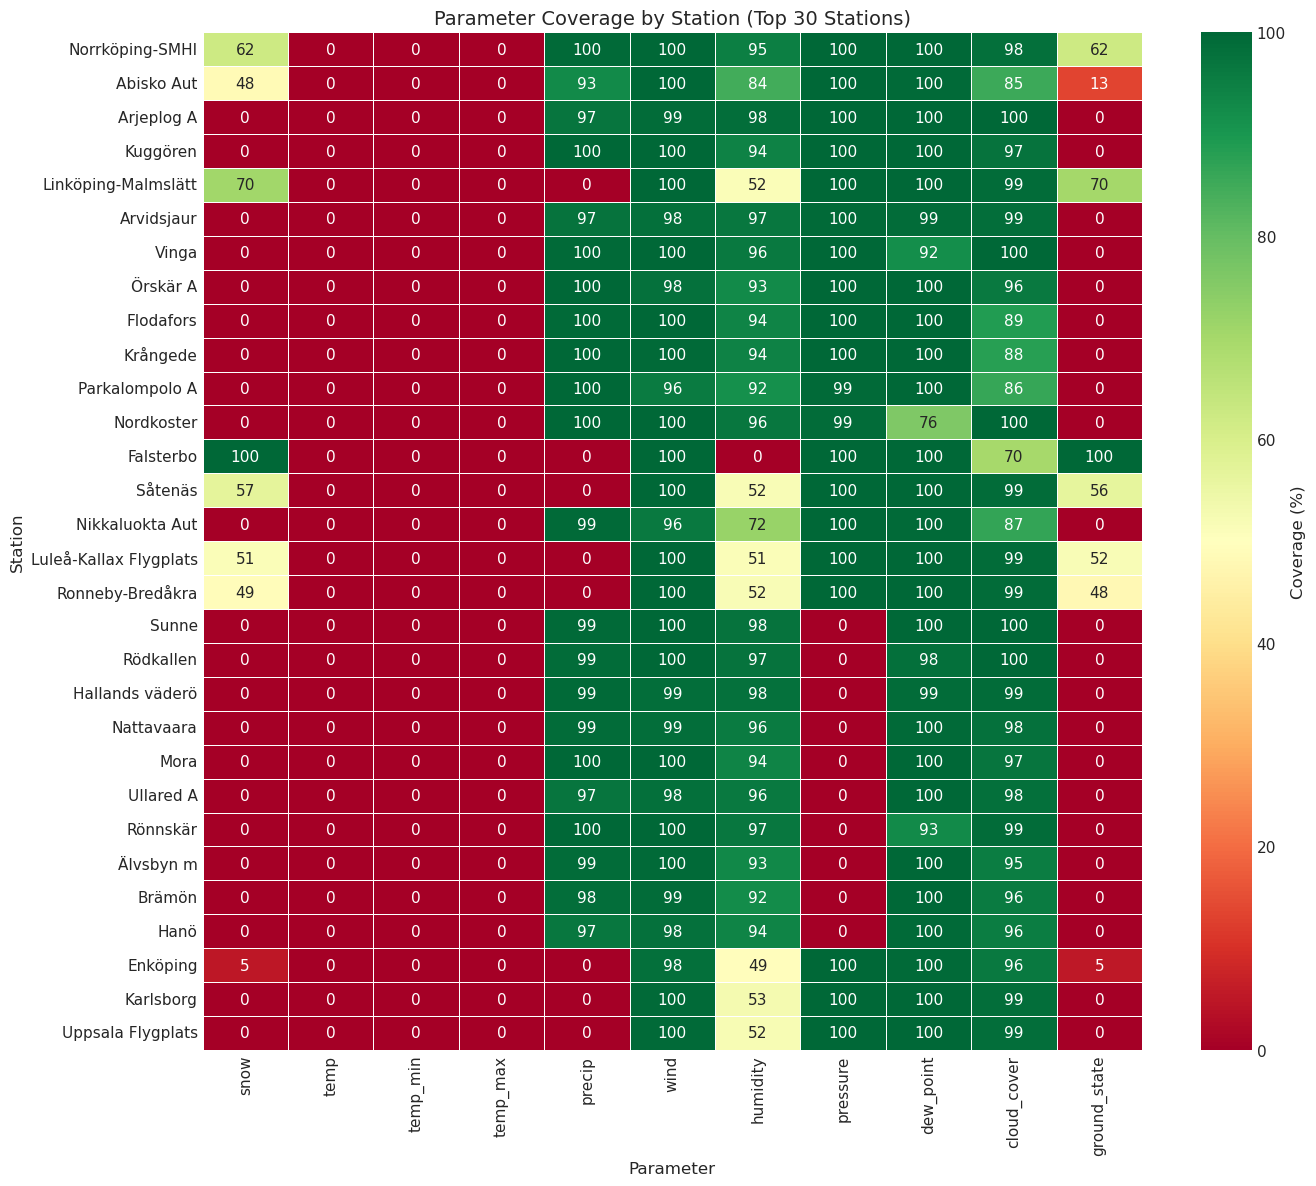

In [31]:
# Heatmap of station-parameter coverage (top 30 stations)
fig, ax = plt.subplots(figsize=(14, 12))

top_30 = station_param_coverage.drop('total_coverage', axis=1).head(30)
sns.heatmap(top_30, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Coverage (%)'})
ax.set_title('Parameter Coverage by Station (Top 30 Stations)', fontsize=14)
ax.set_xlabel('Parameter')
ax.set_ylabel('Station')

plt.tight_layout()
plt.show()

---
# Part 10: Summary & Recommendations

Based on our comprehensive analysis, here are the key findings and recommendations for model training.

In [32]:
# Final summary
print("=" * 100)
print("FINAL SUMMARY")
print("=" * 100)

summary = f"""
DATASET OVERVIEW:
  • Total records: {len(df):,}
  • Total stations: {df['station_id'].nunique()}
  • Date range: {df['date'].min().date()} to {df['date'].max().date()}
  • Parameters: {len(PARAM_COLS)} ({', '.join(PARAM_COLS)})

PARAMETER COVERAGE:
"""
print(summary)

for _, row in coverage_df.iterrows():
    status = "✅" if row['Coverage %'] >= 50 else "⚠️" if row['Coverage %'] >= 20 else "❌"
    print(f"  {status} {row['Parameter']:<15}: {row['Coverage %']:>6.1f}% ({row['Non-Null']:>10,} records)")

FINAL SUMMARY

DATASET OVERVIEW:
  • Total records: 825,584
  • Total stations: 271
  • Date range: 2015-01-01 to 2025-10-01
  • Parameters: 11 (snow, temp, temp_min, temp_max, precip, wind, humidity, pressure, dew_point, cloud_cover, ground_state)

PARAMETER COVERAGE:

  ✅ ground_state   :   68.2% (   563,205 records)
  ✅ snow           :   67.0% (   553,042 records)
  ⚠️ wind           :   33.4% (   275,618 records)
  ⚠️ dew_point      :   33.1% (   273,332 records)
  ⚠️ pressure       :   25.2% (   208,198 records)
  ❌ cloud_cover    :   19.0% (   156,875 records)
  ❌ humidity       :   18.0% (   148,751 records)
  ❌ precip         :   14.9% (   122,893 records)
  ❌ temp           :    0.0% (         0 records)
  ❌ temp_min       :    0.0% (         0 records)
  ❌ temp_max       :    0.0% (         0 records)


In [33]:
# Recommendations
print("\n" + "=" * 100)
print("RECOMMENDATIONS FOR MODEL TRAINING")
print("=" * 100)

recommendations = f"""
1. PRIMARY TARGET:
   • Use 'snow' (depth in meters) as the target variable
   • Coverage: {coverage_df[coverage_df['Parameter']=='snow']['Coverage %'].values[0]:.1f}%
   • Convert to cm for interpretability (snow * 100)

2. RECOMMENDED INPUT FEATURES (by coverage):
"""
print(recommendations)

# List features by coverage
for _, row in coverage_df.iterrows():
    if row['Coverage %'] >= 20 and row['Parameter'] != 'snow':
        print(f"   • {row['Parameter']}: {row['Coverage %']:.1f}%")

print(f"""
3. LOCATION FEATURES (always available):
   • latitude, longitude, elevation
   • day_sin, day_cos (cyclical encoding of day_of_year)

4. DATA CLEANING NEEDED:
   • Remove/clip negative snow values ({(df['snow'] < 0).sum()} records)
   • Handle missing values (imputation or masking)
   • Remove duplicate station-date pairs ({df.duplicated(subset=['station_id', 'date']).sum()} found)

5. TRAIN/VAL/TEST SPLIT:
   • Train: 2015-2021 (7 years)
   • Validation: 2022 (1 year)
   • Test: 2023-2025 (2-3 years)

6. STATIONS TO FOCUS ON:
   • Select stations with >50% overall coverage
   • Ensure geographic diversity (north/south, coastal/inland)
""")


RECOMMENDATIONS FOR MODEL TRAINING

1. PRIMARY TARGET:
   • Use 'snow' (depth in meters) as the target variable
   • Coverage: 67.0%
   • Convert to cm for interpretability (snow * 100)

2. RECOMMENDED INPUT FEATURES (by coverage):

   • ground_state: 68.2%
   • wind: 33.4%
   • dew_point: 33.1%
   • pressure: 25.2%

3. LOCATION FEATURES (always available):
   • latitude, longitude, elevation
   • day_sin, day_cos (cyclical encoding of day_of_year)

4. DATA CLEANING NEEDED:
   • Remove/clip negative snow values (370 records)
   • Handle missing values (imputation or masking)
   • Remove duplicate station-date pairs (0 found)

5. TRAIN/VAL/TEST SPLIT:
   • Train: 2015-2021 (7 years)
   • Validation: 2022 (1 year)
   • Test: 2023-2025 (2-3 years)

6. STATIONS TO FOCUS ON:
   • Select stations with >50% overall coverage
   • Ensure geographic diversity (north/south, coastal/inland)



In [34]:
# Save summary statistics
print("\n" + "=" * 100)
print("SAVING ANALYSIS RESULTS")
print("=" * 100)

# Save coverage stats
coverage_df.to_csv('../data/raw/metro_all_coverage_stats.csv', index=False)
print("✓ Saved: metro_all_coverage_stats.csv")

# Save station stats
station_stats.to_csv('../data/raw/metro_all_station_stats.csv', index=False)
print("✓ Saved: metro_all_station_stats.csv")

# Save station-parameter matrix
station_param_coverage.to_csv('../data/raw/metro_all_station_param_matrix.csv')
print("✓ Saved: metro_all_station_param_matrix.csv")

print("\nAnalysis complete!")


SAVING ANALYSIS RESULTS
✓ Saved: metro_all_coverage_stats.csv
✓ Saved: metro_all_station_stats.csv
✓ Saved: metro_all_station_param_matrix.csv

Analysis complete!


---
# Appendix: Quick Reference

## Dataset File
- **File**: `data/raw/smhi_metro_all.csv`
- **Size**: ~825K records
- **Stations**: Dynamically discovered (3+ parameters including snow)

## Key Findings
1. Snow depth has good coverage across many stations
2. Temperature data is sparse - consider using dew_point as proxy
3. Wind, pressure, dew_point have moderate-to-good coverage
4. Precipitation and humidity have lower coverage

## Suggested Model Features
```python
features = [
    # Target
    'snow',           # Snow depth (m)
    
    # Meteorological (by coverage)
    'dew_point',      # Good coverage, temperature proxy
    'wind',           # Wind speed
    'pressure',       # Sea-level pressure
    'cloud_cover',    # Cloud cover %
    
    # Location
    'latitude',
    'longitude', 
    'elevation',
    
    # Temporal (computed)
    'day_sin',        # sin(2π * day_of_year / 365)
    'day_cos',        # cos(2π * day_of_year / 365)
]
```